In [1]:
import numpy as np
import sys, os, re, math
import torch
from torch_geometric.loader import DataLoader
from model import GCN
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.lines import Line2D
import matplotlib.cm as cm

In [2]:
ds_dir = "../datasets"
gnns_dir = "../gnns"
version = "v4"
proteomeid_dict = {"HUMAN" : "UP000005640_9606",
                   "MOUSE" : "UP000000589_10090",
                   "RAT" : "UP000002494_10116",
                   "YEAST" : "UP000002311_559292"
                  }
annotation = "binding"

bs = 128 #batch size

In [3]:
include_random = True #compute roc for random guessing strategies?

if include_random:
    
    rand_dict = {
    "5050": ["Random (50%)", #label for plot
             "#A0522D"], #color for plot
    "fraction": ["Random (1.6% " + '\u2013' + " 1.9%)",
                 "#D2B48C"]
    }
    
    frac_dict = {"HUMAN" : 0.017,
                 "MOUSE" : 0.016,
                 "RAT" : 0.017, 
                 "YEAST" : 0.019
                }

In [4]:
#define cutoff data
data_dict = {
    "cutoff4" : {
        'label' : "4 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff4_1282",
        'hidden_neurons' : [112],
        'dropout_rates' : [0.276],
        'graph_type' : "cutoff4_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(7)},
    "cutoff6" : {
        'label' : "6 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff6_1282",
        'hidden_neurons' : [118],
        'dropout_rates' : [0.308],
        'graph_type' : "cutoff6_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(6)},
    "cutoff8" : {
        'label' : "8 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff8_1282",
        'hidden_neurons' : [297],
        'dropout_rates' : [0.439],
        'graph_type' : "cutoff8_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(5)},
    "cutoff10" : {
        'label' : "10 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff10_1282",
        'hidden_neurons' : [85],
        'dropout_rates' : [0.648],
        'graph_type' : "cutoff10_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.Accent(4)},
    "cutoff12": {
        'label' : "12 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff12_1282",
        'hidden_neurons' : [322],
        'dropout_rates' : [0.295],
        'graph_type' : "cutoff12_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(0)},
    "cutoff16": {
        'label' : "16 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff16_1282",
        'hidden_neurons' : [59],
        'dropout_rates' : [0.263],
        'graph_type' : "cutoff16_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(1)},
    "cutoff20": {
        'label' : "20 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff20_1282",
        'hidden_neurons' : [44],
        'dropout_rates' : [0.693],
        'graph_type' : "cutoff20_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(2)},
    "cutoff24": {
        'label' : "24 $\mathrm{\AA}$",
        'model_path' : gnns_dir + "/model_cutoff24_1282",
        'hidden_neurons' : [9],
        'dropout_rates' : [0.507],
        'graph_type' : "cutoff24_phipsi_esm2embeddings",
        'linestyle' : '-',
        'color' : cm.tab20c(3)}
}

In [5]:
if include_random:
    #compute the precision-recall curves of each random strategy
    #save the corresponding precision, recall, average precision into a dictionary
    rand5050_prc_auc_dict = {} #key = data_key; value = [[human-precision, recall, average precision],[mouse],[rat],[yeast]]
    randfrac_prc_auc_dict = {} #key = data_key; value = [[human-precision, recall, average precision],[mouse],[rat],[yeast]]
    for data_key in data_dict.keys():
        rand5050_prc_auc_dict[data_key] = [] #initialization
        randfrac_prc_auc_dict[data_key] = [] 
        
    for organism, proteomeid in proteomeid_dict.items():
        
        for data_key in data_dict.keys():
            
            torch.manual_seed(12345)
            
            #load the dataset
            graph_type = data_dict[data_key]['graph_type']
            dataset_graphs = ds_dir + "/" + proteomeid + "_" + organism + "_" + version + "_" + annotation + "_" + graph_type + ".pt"
            dataset = torch.load(dataset_graphs)
            out_labels = dataset[0].y.size()[1]
            
            #create batches
            data_loader = DataLoader(dataset, batch_size=bs, shuffle=False) #shuffle=True when training; turn it off here for testing
            
            for strategy in rand_dict.keys():
                print (organism, data_key, strategy)
                if strategy == 'fraction':
                    for d in range(len(dataset)):
                        data = dataset[d]
                        num_nodes = data.num_nodes
                        y_rand = np.zeros((num_nodes, out_labels))
                        num_nodes_rand = round(num_nodes * frac_dict[organism]) #select x% of the nodes of a graph
                        rand_indices = torch.randperm(num_nodes)[:num_nodes_rand]
                        y_rand[rand_indices] = 1
                        pred_rand = torch.tensor(y_rand, dtype=torch.float64)
                        data.y_rand = pred_rand
                        
                #random guess
                y_score = torch.empty(0)
                y_true = torch.empty(0)
                for i, data in enumerate(data_loader):
                    if strategy == '5050':
                        pred = torch.rand(data.y.size(), dtype=torch.float64)
                        
                    elif strategy == 'fraction':
                        pred = data.y_rand
    
                    target = data.y.type(torch.float) #convert target type from int to float
                    y_score = torch.cat((y_score, pred), dim = 0)
                    y_true = torch.cat((y_true, target), dim = 0)
                
                precision, recall, thresholds = precision_recall_curve(y_true, y_score)
                ap = average_precision_score(y_true, y_score) #average_precision
    
                if strategy == '5050':
                    rand5050_prc_auc_dict[data_key].append([precision, recall, ap])
    
                elif strategy == 'fraction':
                    randfrac_prc_auc_dict[data_key].append([precision, recall, ap])
                    
            del dataset

HUMAN cutoff4 5050
HUMAN cutoff4 fraction
HUMAN cutoff6 5050
HUMAN cutoff6 fraction
HUMAN cutoff8 5050
HUMAN cutoff8 fraction
HUMAN cutoff10 5050
HUMAN cutoff10 fraction
HUMAN cutoff12 5050
HUMAN cutoff12 fraction
HUMAN cutoff16 5050
HUMAN cutoff16 fraction
HUMAN cutoff20 5050
HUMAN cutoff20 fraction
HUMAN cutoff24 5050
HUMAN cutoff24 fraction
MOUSE cutoff4 5050
MOUSE cutoff4 fraction
MOUSE cutoff6 5050
MOUSE cutoff6 fraction
MOUSE cutoff8 5050
MOUSE cutoff8 fraction
MOUSE cutoff10 5050
MOUSE cutoff10 fraction
MOUSE cutoff12 5050
MOUSE cutoff12 fraction
MOUSE cutoff16 5050
MOUSE cutoff16 fraction
MOUSE cutoff20 5050
MOUSE cutoff20 fraction
MOUSE cutoff24 5050
MOUSE cutoff24 fraction
RAT cutoff4 5050
RAT cutoff4 fraction
RAT cutoff6 5050
RAT cutoff6 fraction
RAT cutoff8 5050
RAT cutoff8 fraction
RAT cutoff10 5050
RAT cutoff10 fraction
RAT cutoff12 5050
RAT cutoff12 fraction
RAT cutoff16 5050
RAT cutoff16 fraction
RAT cutoff20 5050
RAT cutoff20 fraction
RAT cutoff24 5050
RAT cutoff24 fra

In [6]:
#compute the prc curves of each model/graph combination
#save the corresponding recall, precision, prc_auc into a dictionary
data_prc_auc_dict = {} #key = data_key; value = [[human-precision, recall, ap],[mouse],[rat],[yeast]]
for data_key in data_dict.keys():
    data_prc_auc_dict[data_key] = [] #initialization

for organism, proteomeid in proteomeid_dict.items():
    
    for data_key in data_dict.keys():
        
        print (organism, data_key)
        
        torch.manual_seed(12345)
        
        model_path = data_dict[data_key]['model_path']
        hidden_neurons = data_dict[data_key]['hidden_neurons']
        dropout_rates = data_dict[data_key]['dropout_rates']
        graph_type = data_dict[data_key]['graph_type']
        
        #load the dataset
        dataset_graphs = ds_dir + "/" + proteomeid + "_" + organism + "_" + version + "_" + annotation + "_" + graph_type + ".pt"
        dataset = torch.load(dataset_graphs)
        inp_node_features = dataset[0].x.size()[1]
        out_labels = dataset[0].y.size()[1]

        #create batches
        data_loader = DataLoader(dataset, batch_size=bs, shuffle=False) #shuffle=True when training; turn it off here for testing

        #load model
        neurons = [inp_node_features] + hidden_neurons + [out_labels] #neurons in each layer
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = GCN(neurons).to(device)
        model.load_state_dict(torch.load(model_path))

        #evaluation
        y_score = torch.empty(0)
        y_true = torch.empty(0)
        for data in data_loader:
            model.eval()
            with torch.no_grad():
                pred = model(data, dropout_rates)
                y_score = torch.cat((y_score, pred), dim = 0)
            target = data.y.type(torch.float)
            y_true = torch.cat((y_true, target), dim = 0)
        
        #compute prc curve and prc area
        precision, recall, thresholds = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)
        
        data_prc_auc_dict[data_key].append([precision, recall, ap])
        
        del dataset

HUMAN cutoff4
HUMAN cutoff6
HUMAN cutoff8
HUMAN cutoff10
HUMAN cutoff12
HUMAN cutoff16
HUMAN cutoff20
HUMAN cutoff24
MOUSE cutoff4
MOUSE cutoff6
MOUSE cutoff8
MOUSE cutoff10
MOUSE cutoff12
MOUSE cutoff16
MOUSE cutoff20
MOUSE cutoff24
RAT cutoff4
RAT cutoff6
RAT cutoff8
RAT cutoff10
RAT cutoff12
RAT cutoff16
RAT cutoff20
RAT cutoff24
YEAST cutoff4
YEAST cutoff6
YEAST cutoff8
YEAST cutoff10
YEAST cutoff12
YEAST cutoff16
YEAST cutoff20
YEAST cutoff24


In [7]:
#create label
label_dict = {} #key = data_key; value = label
for data_key in data_dict.keys():
    prc_auc1 = data_prc_auc_dict[data_key][0][2] #human
    prc_auc2 = data_prc_auc_dict[data_key][1][2] #mouse
    prc_auc3 = data_prc_auc_dict[data_key][2][2] #rat
    prc_auc4 = data_prc_auc_dict[data_key][3][2] #yeast
    label_dict[data_key] = data_dict[data_key]['label'] + ': ' + '%0.2f' % prc_auc1 + ' ' + '%0.2f' % prc_auc2 + ' ' + '%0.2f' % prc_auc3 + ' ' + '%0.2f' % prc_auc4

if include_random:
    rand5050_prc_auc = []
    for data_key in data_dict.keys():
        for x in range(len((proteomeid_dict.keys()))):
            rand_prc_auc = rand5050_prc_auc_dict[data_key][x][2]
            rand5050_prc_auc.append(rand_prc_auc)
    rand5050_label = rand_dict["5050"][0] + ': ' + '%0.2f' % np.average(rand5050_prc_auc) + ' \u00b1 ' + '%0.2f' % np.std(rand5050_prc_auc)
    
    randfrac_prc_auc = []
    for data_key in data_dict.keys():
        for x in range(len((proteomeid_dict.keys()))):
            rand_prc_auc = randfrac_prc_auc_dict[data_key][x][2]
            randfrac_prc_auc.append(rand_prc_auc)
    randfrac_label = rand_dict["fraction"][0] + ': ' + '%0.2f' % np.average(randfrac_prc_auc) + ' \u00b1 ' + '%0.2f' % np.std(randfrac_prc_auc)

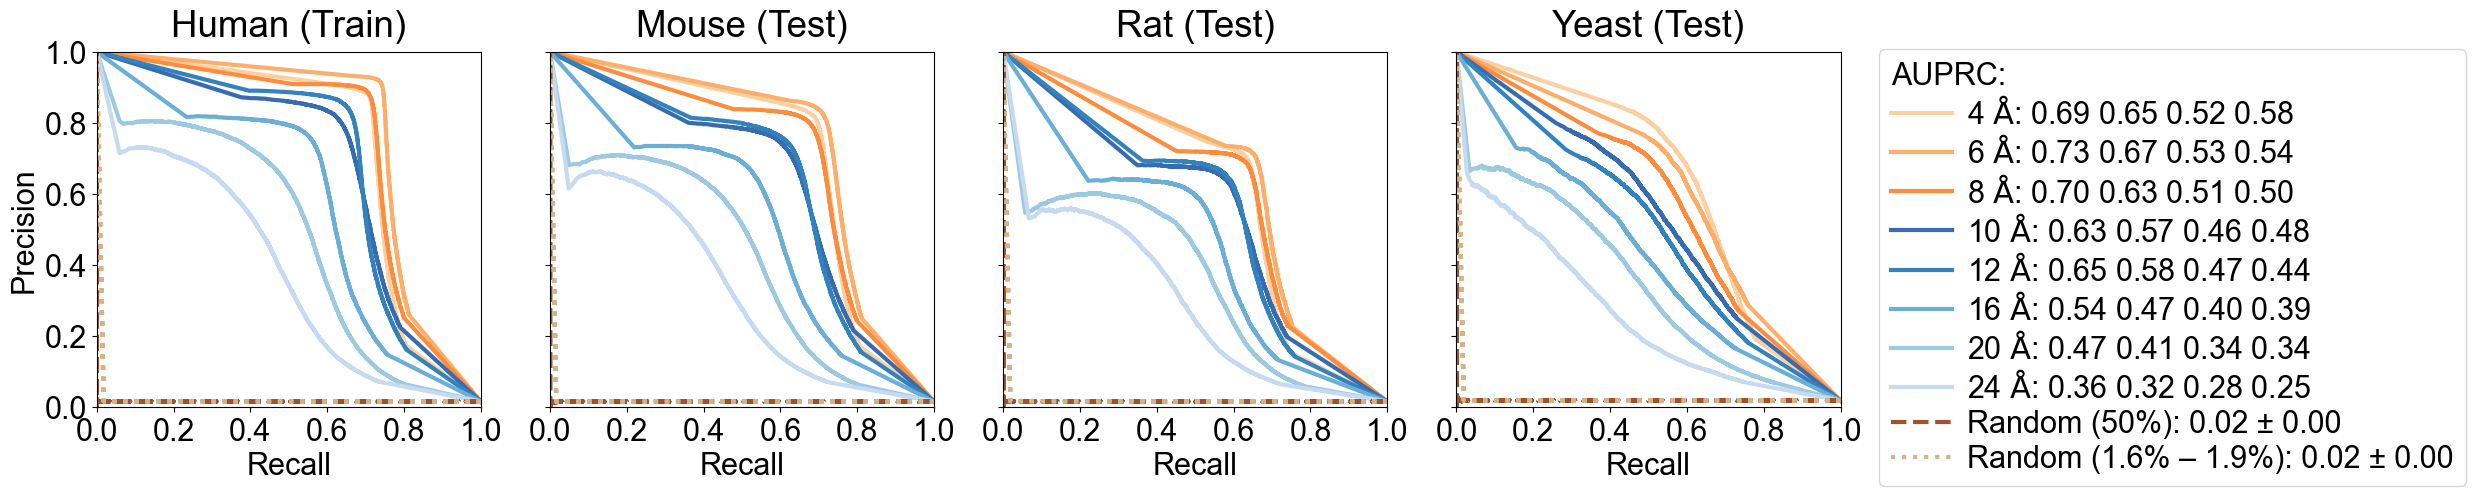

In [8]:
#plot precision-recall curves
mpl.rcParams['font.sans-serif'] = "Arial"
plt.rcParams.update({'font.size': 22})
fig, axes = plt.subplots(nrows=1, ncols=len(proteomeid_dict.keys()), sharex=True, sharey=True, figsize=(22.5,4.5))
plt.subplots_adjust(top=0.90, wspace=0.18)

axes = axes.flatten()

for x, organism in enumerate(proteomeid_dict.keys()): #col
    torch.manual_seed(12345)
    ax = axes[x]
    
    for data_key in data_dict.keys():
        label = label_dict[data_key]
        color = data_dict[data_key]['color']
        linestyle = data_dict[data_key]['linestyle']
        precision = data_prc_auc_dict[data_key][x][0]
        recall = data_prc_auc_dict[data_key][x][1]
        prc_auc = data_prc_auc_dict[data_key][x][2]
        
        ax.plot(recall, precision, color=color, linewidth=3, linestyle=linestyle, label=label)

    if include_random:
        for data_key in rand5050_prc_auc_dict.keys():
            label = rand5050_label
            color = rand_dict["5050"][1]
            precision = rand5050_prc_auc_dict[data_key][x][0]
            recall = rand5050_prc_auc_dict[data_key][x][1]
            prc_auc = rand5050_prc_auc_dict[data_key][x][2]
            
            ax.plot(recall, precision, color=color, linewidth=3, linestyle="--", label=label)
            
        for data_key in randfrac_prc_auc_dict.keys():
            label = randfrac_label
            color = rand_dict["fraction"][1]
            precision = randfrac_prc_auc_dict[data_key][x][0]
            recall = randfrac_prc_auc_dict[data_key][x][1]
            prc_auc = randfrac_prc_auc_dict[data_key][x][2]
            
            ax.plot(recall, precision, color=color, linewidth=3, linestyle=":", label=label)
            
    if x == len(proteomeid_dict.keys()) - 1:
        # Create a unique set of handles and labels
        h, l = ax.get_legend_handles_labels()
        unique_handles = []
        unique_labels = []
        for handle, label in zip(h, l):
            if label not in unique_labels:
                unique_handles.append(handle)
                unique_labels.append(label)
        leg = ax.legend(unique_handles, unique_labels, frameon=True, bbox_to_anchor = (1.06, 1.05), markerscale=1, labelspacing=0.2, handletextpad=0.5)
        
        leg.set_title("AUPRC:")
        leg._legend_box.align = "left"
        
    elif x == 0:
        ax.set_ylabel('Precision')
        
    if organism == 'HUMAN':
        title = organism.title() + " (Train)"
    else:
        title = organism.title() + " (Test)"

    ax.set_title(title, y=1.02)
    ax.set_xlim([0,1.0])
    ax.set_ylim([0,1.0])
    ticks = np.arange(0, 1.1, 0.2)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlabel('Recall')

plt.show()


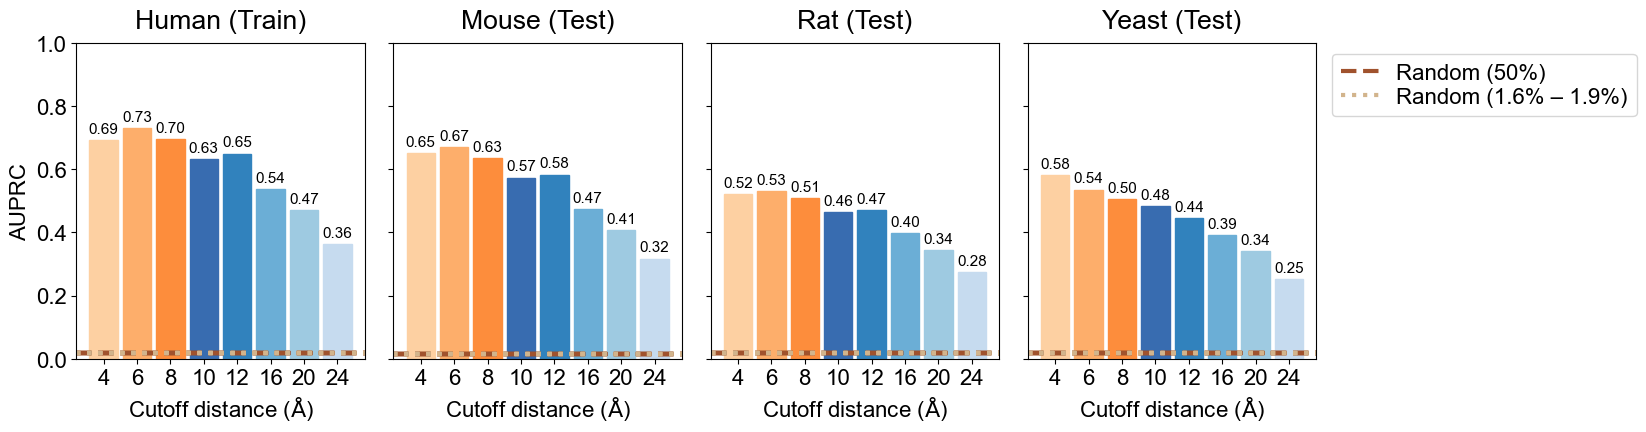

In [9]:
#plot AUPRC values
mpl.rcParams['font.sans-serif'] = "Arial"
plt.rcParams.update({'font.size': 16})
fig, axes = plt.subplots(nrows=1, ncols=len(proteomeid_dict.keys()), sharex=True, sharey=True, figsize=(16,4))
plt.subplots_adjust(top=0.90, wspace=0.10)

axes = axes.flatten()
width = 0.85 
for x, organism in enumerate(proteomeid_dict.keys()): #col
    torch.manual_seed(12345)
    ax = axes[x]
    
    for i, data_key in enumerate(data_dict.keys()):
        label = data_dict[data_key]['label']
        color = data_dict[data_key]['color']
        linestyle = data_dict[data_key]['linestyle']
        precision = data_prc_auc_dict[data_key][x][0]
        recall = data_prc_auc_dict[data_key][x][1]
        prc_auc = data_prc_auc_dict[data_key][x][2]
        p = ax.bar(i, prc_auc, width, color=color, edgecolor=color)
        ax.bar_label(p, fmt='{:,.2f}', padding=3, fontsize = 11)
        
    if include_random:
        for data_key in rand5050_prc_auc_dict.keys():
            label = rand_dict["5050"][0]
            color = rand_dict["5050"][1]
            precision = rand5050_prc_auc_dict[data_key][x][0]
            recall = rand5050_prc_auc_dict[data_key][x][1]
            prc_auc = rand5050_prc_auc_dict[data_key][x][2]
            ax.axhline(prc_auc, color=color, linewidth=3, linestyle="--", label=label)
            
        for data_key in randfrac_prc_auc_dict.keys():
            label = rand_dict["fraction"][0]
            color = rand_dict["fraction"][1]
            precision = randfrac_prc_auc_dict[data_key][x][0]
            recall = randfrac_prc_auc_dict[data_key][x][1]
            prc_auc = randfrac_prc_auc_dict[data_key][x][2]
            ax.axhline(prc_auc, color=color, linewidth=3, linestyle=":", label=label)
            
    if x == len(proteomeid_dict.keys()) - 1:
        # Create a unique set of handles and labels
        h, l = ax.get_legend_handles_labels()
        unique_handles = []
        unique_labels = []
        for handle, label in zip(h, l):
            if label not in unique_labels:
                unique_handles.append(handle)
                unique_labels.append(label)
        leg = ax.legend(unique_handles, unique_labels, frameon=True, bbox_to_anchor = (2.15, 1.0), markerscale=1, labelspacing=0.2, handletextpad=0.5)
        leg._legend_box.align = "left"
        
    elif x == 0:
        ax.set_ylabel('AUPRC')
        
    if organism == 'HUMAN':
        title = organism.title() + " (Train)"
    else:
        title = organism.title() + " (Test)"

    ax.set_title(title, y=1.02)
    #ax.set_xlim([0,1.0])
    ax.set_xticks([0,1,2,3,4,5,6,7])
    ax.set_xticklabels(["4", "6", "8", "10", "12", "16", "20", "24"])
    ax.set_ylim([0,1.0])
    ticks = np.arange(0, 1.1, 0.2)
    #ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlabel('Cutoff distance ($\mathrm{\AA}$)')

plt.show()
